> **1º turno da eleição presidencial de 2022 (2/10/2022).** Notebook de outubro de 2022, rodado de novo em outubro de 2026, fora do Colab, com os mesmos dados do TSE de 2022 e as coordenadas oficiais das zonas (notebook 01). O código é o original, com as mudanças listadas no [README](../README.md#sobre-esta-versão).

In [1]:
import os
import shutil

import pandas as pd
import numpy as np
import geopandas as gpd

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

In [2]:
PASTA_DO_PROJETO = '..'  # raiz do repositório

# Lê Dados das Votações por Seção Eleitoral

In [3]:
#Arquivos baixados do site do TSE
#https://dadosabertos.tse.jus.br/dataset/resultados-2022
#https://dadosabertos.tse.jus.br/dataset/resultados-2022-boletim-de-urna

#Outra Opção de Fonte:
#https://basedosdados.org/dataset/br-tse-eleicoes?bdm_table=resultados_candidato_secao

path_dados = f'{PASTA_DO_PROJETO}/dados_votacao'
lista_arquivos = ['detalhe_votacao_secao_2022.zip', 'votacao_secao_2022_BR.zip']
print(lista_arquivos)

path_dados_boletim = f'{PASTA_DO_PROJETO}/dados_boletim_urna'
lista_arquivos_boletim = os.listdir(path_dados_boletim)
print(len(lista_arquivos_boletim))

path_dados_geocodificacao = f'{PASTA_DO_PROJETO}/dados_coordenadas_zonas'
lista_arquivos_geo = os.listdir(path_dados_geocodificacao)
print(lista_arquivos_geo)

['detalhe_votacao_secao_2022.zip', 'votacao_secao_2022_BR.zip']
28
['coordenadas_zonas_eleitorais_2022.csv']


In [4]:
#Descompacta os arquivos
for arq in lista_arquivos:
    pasta = arq.split('.')[0]
    shutil.unpack_archive(f'{path_dados}/{arq}', pasta)

In [5]:
def leitura_dados(pasta, arq_csv, colunas):
    #Lê só as colunas usadas, para caber na memória
    return pd.read_csv(f'{pasta}/{arq_csv}', sep = ';', engine = 'c', encoding = 'latin-1', usecols = colunas)

arq = 'detalhe_votacao_secao_2022.zip'
pasta = arq.split('.')[0]
arq_csv = [f for f in os.listdir(pasta) if f.find('.csv') != -1 and f.find('_BRASIL') != -1][0]
df_desc_inp = leitura_dados(pasta, arq_csv, ['NR_TURNO', 'DS_CARGO', 'SG_UF', 'NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO',
                                             'QT_APTOS', 'QT_COMPARECIMENTO', 'QT_ABSTENCOES', 'QT_VOTOS_NOMINAIS',
                                             'QT_VOTOS_BRANCOS', 'QT_VOTOS_NULOS'])

arq = 'votacao_secao_2022_BR.zip'
pasta = arq.split('.')[0]
arq_csv = [f for f in os.listdir(pasta) if f.find('.csv') != -1][0]
df_inp = leitura_dados(pasta, arq_csv, ['NR_TURNO', 'DS_CARGO', 'SG_UF', 'NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO',
                                       'NM_VOTAVEL', 'QT_VOTOS'])

In [6]:
def trata_detalhe(df_desc_inp):
    df_desc = df_desc_inp[(df_desc_inp['DS_CARGO'] == 'PRESIDENTE') & (df_desc_inp['NR_TURNO'] == 1)]
    cols_id = ['SG_UF', 'NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO']
    cols_info = ['QT_APTOS', 'QT_COMPARECIMENTO', 'QT_ABSTENCOES', 'QT_VOTOS_NOMINAIS', 'QT_VOTOS_BRANCOS', 'QT_VOTOS_NULOS']
    df_desc = df_desc[np.append(cols_id, cols_info)].reset_index(drop = True)
    return df_desc.reset_index().rename({'index': 'ID_URNA'}, axis = 1).copy()

def trata_votacao(df_inp, df_desc):
    df = df_inp[(df_inp['DS_CARGO'] == 'PRESIDENTE') & (df_inp['NR_TURNO'] == 1)]
    cols_id = ['SG_UF', 'NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO', 'NM_VOTAVEL']
    cols_info = ['QT_VOTOS']
    df = df[np.append(cols_id, cols_info)].reset_index(drop = True).copy()
    cols_urna = ['ID_URNA', 'SG_UF', 'NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO']
    return pd.merge(df, df_desc[cols_urna], how = 'left', on = ['SG_UF', 'NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO'])

In [7]:
df_desc = trata_detalhe(df_desc_inp)
df_desc.sample(n = 5).T

,299853,365649,146960,263311,171496
ID_URNA,299853,365649,146960,263311,171496
SG_UF,SP,PA,PE,PE,SP
NM_MUNICIPIO,SANTANA DE PARNAÍBA,TUCURUÍ,SANTA CRUZ DO CAPIBARIBE,CAPOEIRAS,TAUBATÉ
NR_ZONA,386,40,109,130,407
NR_SECAO,396,84,61,42,392
QT_APTOS,393,346,334,377,387
QT_COMPARECIMENTO,336,246,298,273,332
QT_ABSTENCOES,57,100,36,104,55
QT_VOTOS_NOMINAIS,312,241,284,264,312
QT_VOTOS_BRANCOS,13,2,6,1,9


In [8]:
df = trata_votacao(df_inp, df_desc)
df.sample(n = 5).T

,547732,259023,3345918,2394750,878769
SG_UF,PA,BA,SP,PR,PI
NM_MUNICIPIO,ELDORADO DOS CARAJÁS,ILHÉUS,GUARULHOS,FOZ DO IGUAÇU,ACAUÃ
NR_ZONA,58,26,279,147,38
NR_SECAO,189,228,101,52,14
NM_VOTAVEL,LUIZ INÁCIO LULA DA SILVA,VOTO NULO,SORAYA VIEIRA THRONICKE,JAIR MESSIAS BOLSONARO,SIMONE NASSAR TEBET
QT_VOTOS,143,12,3,176,1
ID_URNA,259954,64907,469590,379391,23961


In [9]:
df_geocod = pd.read_csv(f'{path_dados_geocodificacao}/coordenadas_zonas_eleitorais_2022.csv')
df_geocod = df_geocod.rename({'sigla_uf': 'SG_UF', 'numero_zona': 'NR_ZONA'}, axis = 1)
df_geocod = df_geocod[['SG_UF', 'NR_ZONA', 'Latitude', 'Longitude']]

df_geocod.sample(n = 5).T

,1571,184,1714,335,2381
SG_UF,PR,BA,RJ,CE,SP
NR_ZONA,103,66,87,16,183
Latitude,-25.85071,-9.239987,-22.845378,-7.249723,-23.699614
Longitude,-52.529331,-41.336114,-43.077658,-39.143159,-46.397377


In [10]:
df_desc_geo = pd.merge(df_desc, df_geocod, how = 'left', on = ['SG_UF', 'NR_ZONA'])

df_desc_geo.sample(n = 5).T

,360197,314988,384682,471856,372110
ID_URNA,360197,314988,384682,471856,372110
SG_UF,BA,SP,CE,MG,MT
NM_MUNICIPIO,JUAZEIRO,SÃO PAULO,FORTALEZA,SENHORA DE OLIVEIRA,CÁCERES
NR_ZONA,48,375,115,217,6
NR_SECAO,125,11,403,86,56
QT_APTOS,236,337,345,388,203
QT_COMPARECIMENTO,205,248,281,288,146
QT_ABSTENCOES,31,89,64,100,57
QT_VOTOS_NOMINAIS,193,230,266,268,143
QT_VOTOS_BRANCOS,1,7,3,8,0


# Resultados do 1º Turno de 2022

In [11]:
df_res = df[['NM_VOTAVEL', 'QT_VOTOS']].groupby('NM_VOTAVEL').sum().sort_values('QT_VOTOS', ascending = False)
df_res['PERC_VOTOS'] = df_res['QT_VOTOS']*100/df_res['QT_VOTOS'].sum()
df_res['PERC_VOTOS_VALIDOS'] = df_res['QT_VOTOS']*100/df_res.loc[~df_res.index.isin(['VOTO NULO', 'VOTO BRANCO']), 'QT_VOTOS'].sum()
display(df_res)

,QT_VOTOS,PERC_VOTOS,PERC_VOTOS_VALIDOS
NM_VOTAVEL,,,
LUIZ INÁCIO LULA DA SILVA,57259504,46.295606,48.430720
JAIR MESSIAS BOLSONARO,51072345,41.293148,43.197553
SIMONE NASSAR TEBET,4915423,3.974231,4.157519
CIRO FERREIRA GOMES,3599287,2.910105,3.044317
VOTO NULO,3487874,2.820025,2.950082
VOTO BRANCO,1964779,1.588568,1.661832
SORAYA VIEIRA THRONICKE,600955,0.485886,0.508294
LUIZ FELIPE CHAVES D AVILA,559708,0.452537,0.473407
KELMON LUIS DA SILVA SOUZA,81129,0.065595,0.068620


# Análise por Geolocalização

In [12]:
df_geo = pd.merge(df, df_desc_geo[['ID_URNA', 'Latitude', 'Longitude']], how = 'left', on = 'ID_URNA')

def f(x):
    d = {}
    d['Latitude'] = x['Latitude'].values[0]
    d['Longitude'] = x['Longitude'].values[0]
    d['QT_VOTOS'] = x['QT_VOTOS'].sum()
    return pd.Series(d)

cols = ['SG_UF', 'NR_ZONA', 'NM_VOTAVEL', 'Latitude', 'Longitude', 'QT_VOTOS']
df_geo_agg = df_geo[cols].groupby(['SG_UF', 'NR_ZONA', 'NM_VOTAVEL']).apply(lambda x: f(x)).reset_index()

<célula>:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_geo_agg = df_geo[cols].groupby(['SG_UF', 'NR_ZONA', 'NM_VOTAVEL']).apply(lambda x: f(x)).reset_index()


In [13]:
cols_index = ['SG_UF', 'NR_ZONA', 'Latitude', 'Longitude']
df_geo_pivot = df_geo_agg.pivot(index = cols_index, columns = ['NM_VOTAVEL'], values = 'QT_VOTOS')
candidatos = list(df_geo_pivot.columns)
df_geo_pivot = df_geo_pivot.reset_index()
df_geo_pivot = df_geo_pivot.fillna(0)

series_tot = df_geo_pivot[candidatos].sum(axis = 1)
for col in candidatos:
    df_geo_pivot[col] = df_geo_pivot[col]*100/series_tot

df_geo_pivot = df_geo_pivot[df_geo_pivot['SG_UF'] != 'ZZ']

In [14]:
gdf = gpd.GeoDataFrame(df_geo_pivot[np.append(['Latitude', 'Longitude'], candidatos)], 
                       geometry = gpd.points_from_xy(df_geo_pivot['Longitude'], df_geo_pivot['Latitude']))

In [15]:
path_malhas = f'{PASTA_DO_PROJETO}/dados_malhas_ibge'
#Só os setores da cidade de São Paulo, os únicos usados nos mapas (a malha do país inteiro ocupa uns 3,5 GB de memória)
gdf_setor = gpd.read_file(f'{path_malhas}/BR_Setores_2020.zip', where = "NM_MUN = 'São Paulo' AND SIGLA_UF = 'SP'")
gdf_mun = gpd.read_file(f'{path_malhas}/BR_Municipios_2021.zip')
gdf_uf = gpd.read_file(f'{path_malhas}/BR_UF_2021.zip')
gdf_pais = gpd.read_file(f'{path_malhas}/BR_Pais_2021.zip')

### Expande Dados para o Contorno

In [16]:
#Define o Contorno Convexo
contorno_convex = gdf_pais['geometry'].iloc[0].convex_hull
mask_interior = gdf['geometry'].apply(lambda p: p.within(contorno_convex))
gdf_plot = gdf[mask_interior]

#Expande os valores mais próximos do contorno para os pontos de contorno
df_expand = pd.DataFrame(np.array(gdf_pais.convex_hull.boundary.iloc[0].coords), columns = ['Longitude', 'Latitude'])
gdf_expand = gpd.GeoDataFrame(df_expand, geometry = gpd.points_from_xy(df_expand['Longitude'], df_expand['Latitude']))
def f(x, gdf_plot, candidatos):
    dist = gdf_plot['geometry'].distance(x)
    ret = gdf_plot.loc[dist == dist.min(), candidatos].mean(axis = 0)
    return ret
gdf_expand = pd.concat([gdf_expand, gdf_expand['geometry'].apply(lambda x: f(x, gdf_plot, candidatos))], axis = 1)

#Adiciona os pontos de contorno expandidos
gdf_plot = pd.concat([gdf_plot, gdf_expand])

In [17]:
paleta_cores = sns.color_palette("colorblind")

dict_cores = {'LUIZ INÁCIO LULA DA SILVA': (1, 0, 0),
              'JAIR MESSIAS BOLSONARO': (0, 0, 1),
              #'SIMONE NASSAR TEBET': (1, 1, 0)
              }
#dict_cores = {'LUIZ INÁCIO LULA DA SILVA': paleta_cores[1],
#              'JAIR MESSIAS BOLSONARO': paleta_cores[0],
#              #'SIMONE NASSAR TEBET': paleta_cores[2]
#              }
dict_label = {'LUIZ INÁCIO LULA DA SILVA': 'Lula',
              'JAIR MESSIAS BOLSONARO': 'Jair Bolsonaro',
              #'SIMONE NASSAR TEBET': 'Tebet'
              }

candidatos_sel = ['LUIZ INÁCIO LULA DA SILVA', 
                  'JAIR MESSIAS BOLSONARO',
                 #'SIMONE NASSAR TEBET'
                 ]

hlds = []
for k, v in dict_cores.items():
    hlds.append(mpl.patches.Patch(color = v, label = dict_label[k]))

### Mapa País

In [18]:
gdf_contorno = gdf_pais
gdf_contorno_interno = gdf_uf

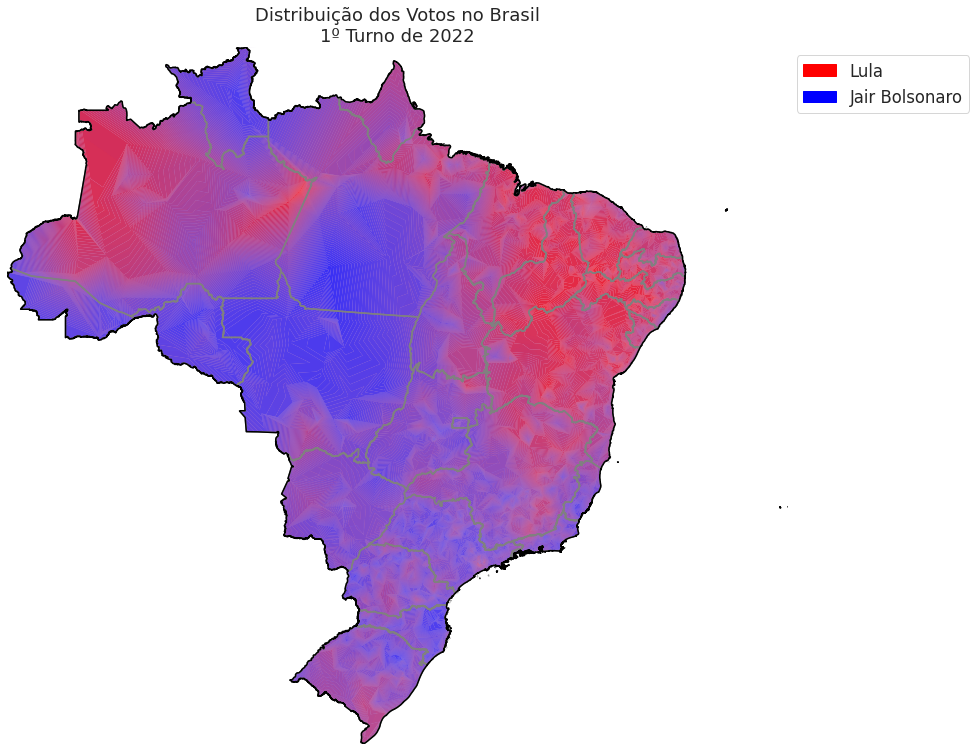

In [19]:
with sns.axes_style("whitegrid"), sns.plotting_context('notebook', font_scale = 1.5):
    fig, ax = plt.subplots(1, 1, figsize = (14, 14))

    x = gdf_plot['Longitude']
    y = gdf_plot['Latitude']
    for candidato in candidatos_sel:
        z = gdf_plot[candidato].fillna(0)

        N = 256
        cor = dict_cores[candidato]
        vals = np.ones((N, 4))
        vals[:, 0] = cor[0]
        vals[:, 1] = cor[1]
        vals[:, 2] = cor[2]
        vals[:, 3] = np.linspace(0, 1, N)[::-1]
        cmap = mpl.colors.ListedColormap(vals[::-1])

        cntr = ax.tricontourf(x, y, z, levels = 100, 
                              cmap = cmap,
                              norm = mpl.colors.Normalize(vmin = 0, vmax = 100, clip = False),
                              linestyles = None, 
                              antialiased = True)
    
    #Limites do gráfico
    df_lim = pd.DataFrame(np.array(gdf_contorno.convex_hull.boundary.iloc[0].coords), columns = ['Longitude', 'Latitude'])
    ax.set_xlim([df_lim['Longitude'].min(), df_lim['Longitude'].max()])
    ax.set_ylim([df_lim['Latitude'].min(), df_lim['Latitude'].max()])
    #Contornos internos
    gdf_contorno_interno['geometry'].boundary.plot(ax = ax, color = 'grey')
    #Contornos externos
    (gdf_contorno['geometry'].envelope.difference(gdf_contorno['geometry'])).plot(ax = ax, color = 'white', edgecolor = None)
    gdf_contorno['geometry'].boundary.plot(ax = ax, color = 'black')
    #Remoção de Grades e Eixos
    ax.grid(False)
    frame = plt.gca()
    frame.axes.xaxis.set_ticklabels([])
    frame.axes.yaxis.set_ticklabels([])

    ax.legend(handles = hlds, bbox_to_anchor = (1.0, 1), loc = 'upper left')
    ax.set_title('Distribuição dos Votos no Brasil\n1º Turno de 2022')
    plt.box(False)
    plt.show()

### Mapa Estado

In [20]:
uf = 'MG'
gdf_contorno = gdf_uf[gdf_uf['SIGLA'] == uf]
gdf_contorno_interno = gdf_mun[gdf_mun['SIGLA'] == uf]

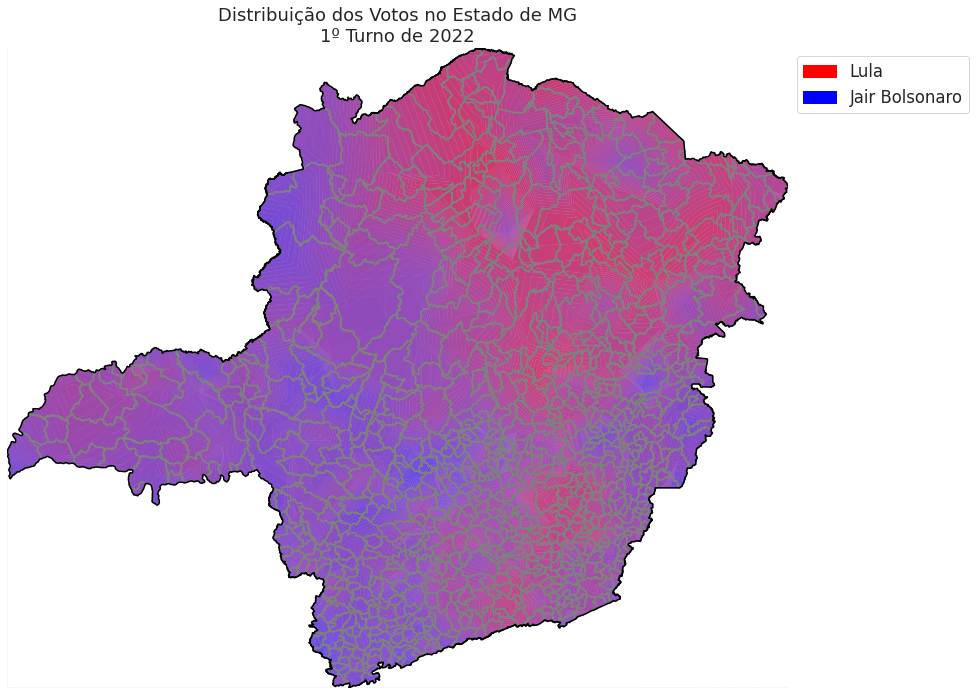

In [21]:
with sns.axes_style("whitegrid"), sns.plotting_context('notebook', font_scale = 1.5):
    fig, ax = plt.subplots(1, 1, figsize = (14, 14))

    x = gdf_plot['Longitude']
    y = gdf_plot['Latitude']
    for candidato in candidatos_sel:
        z = gdf_plot[candidato].fillna(0)

        N = 256
        cor = dict_cores[candidato]
        vals = np.ones((N, 4))
        vals[:, 0] = cor[0]
        vals[:, 1] = cor[1]
        vals[:, 2] = cor[2]
        vals[:, 3] = np.linspace(0, 1, N)[::-1]
        cmap = mpl.colors.ListedColormap(vals[::-1])

        cntr = ax.tricontourf(x, y, z, levels = 100, 
                              cmap = cmap,
                              norm = mpl.colors.Normalize(vmin = 0, vmax = 100, clip = False),
                              linestyles = None, 
                              antialiased = True)

    #Limites do gráfico
    df_lim = pd.DataFrame(np.array(gdf_contorno.convex_hull.boundary.iloc[0].coords), columns = ['Longitude', 'Latitude'])
    ax.set_xlim([df_lim['Longitude'].min(), df_lim['Longitude'].max()])
    ax.set_ylim([df_lim['Latitude'].min(), df_lim['Latitude'].max()])
    #Contornos internos
    gdf_contorno_interno['geometry'].boundary.plot(ax = ax, color = 'grey')
    #Contornos externos
    (gdf_contorno['geometry'].envelope.difference(gdf_contorno['geometry'])).plot(ax = ax, color = 'white', edgecolor = None)
    gdf_contorno['geometry'].boundary.plot(ax = ax, color = 'black')
    #Remoção de Grades e Eixos
    ax.grid(False)
    frame = plt.gca()
    frame.axes.xaxis.set_ticklabels([])
    frame.axes.yaxis.set_ticklabels([])

    ax.legend(handles = hlds, bbox_to_anchor = (1.0, 1), loc = 'upper left')
    ax.set_title(f'Distribuição dos Votos no Estado de {uf}\n1º Turno de 2022')

    plt.box(False)
    plt.show()

### Mapa Cidade

In [22]:
cidade = 'São Paulo'
uf = 'SP'
flag_plot_setores = True

gdf_contorno = gdf_mun[(gdf_mun['NM_MUN'] == cidade) & (gdf_mun['SIGLA'] == uf)]
display(gdf_contorno)

gdf_contorno_interno = gdf_setor[(gdf_setor['NM_MUN'] == cidade) & (gdf_setor['SIGLA_UF'] == uf)]
if(gdf_contorno_interno['CD_DIST'].unique().size > 1):
    agrupamento = 'CD_DIST'
elif(gdf_contorno_interno['CD_SUBDIST'].unique().size > 1):
    agrupamento = 'CD_SUBDIST'
else:
    agrupamento = None
if agrupamento is not None:
    gdf_contorno_interno = gdf_contorno_interno[[agrupamento, 'geometry']].dissolve(by = agrupamento)
print(gdf_contorno_interno.shape)

,CD_MUN,NM_MUN,SIGLA,AREA_KM2,geometry
3829,3550308,São Paulo,SP,1521.202,"POLYGON ((-46.54624 -23.35791, -46.54585 -23.3..."


(96, 1)


In [23]:
flag_plot_zonas_eleitorais = False

contorno_convex_tmp = gdf_contorno['geometry'].iloc[0].convex_hull
mask_interior_temp = gdf['geometry'].apply(lambda p: p.within(contorno_convex_tmp))
mask_interior_temp2 = gdf.loc[mask_interior_temp, 'geometry'].apply(lambda p: p.within(gdf_contorno['geometry'].iloc[0]))
gdf_plot_temp = gdf[mask_interior_temp][mask_interior_temp2.values]
print(gdf_plot_temp.shape)

hlds_temp = hlds.copy()
hlds_temp.append(mpl.lines.Line2D([0], [0], marker = 'o', markerfacecolor = 'black', markersize = 15, color = 'white',
                                  label = 'Zonas Eleitorais'))

(58, 16)


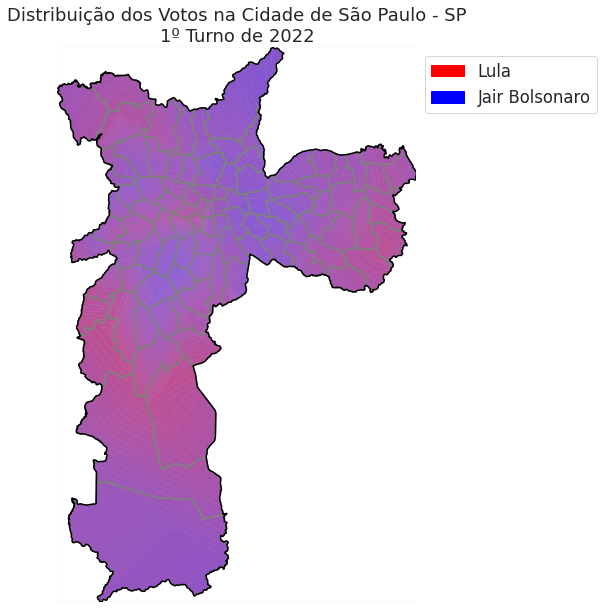

In [24]:
with sns.axes_style("whitegrid"), sns.plotting_context('notebook', font_scale = 1.5):
    fig, ax = plt.subplots(1, 1, figsize = (10, 10))

    x = gdf_plot['Longitude']
    y = gdf_plot['Latitude']
    for candidato in candidatos_sel:
        z = gdf_plot[candidato].fillna(0)

        N = 256
        cor = dict_cores[candidato]
        vals = np.ones((N, 4))
        vals[:, 0] = cor[0]
        vals[:, 1] = cor[1]
        vals[:, 2] = cor[2]
        vals[:, 3] = np.linspace(0, 1, N)[::-1]
        cmap = mpl.colors.ListedColormap(vals[::-1])

        cntr = ax.tricontourf(x, y, z, levels = 100, 
                              cmap = cmap,
                              norm = mpl.colors.Normalize(vmin = 0, vmax = 100, clip = False),
                              linestyles = None, 
                              antialiased = True)

    #Limites do gráfico
    df_lim = pd.DataFrame(np.array(gdf_contorno.convex_hull.boundary.iloc[0].coords), columns = ['Longitude', 'Latitude'])
    ax.set_xlim([df_lim['Longitude'].min(), df_lim['Longitude'].max()])
    ax.set_ylim([df_lim['Latitude'].min(), df_lim['Latitude'].max()])
    #Contornos internos
    if flag_plot_setores:
        gdf_contorno_interno['geometry'].boundary.plot(ax = ax, color = 'grey',
                                                       #lw = 1,
                                                       alpha = 1, 
                                                       )
    #Contornos externos
    (gdf_contorno['geometry'].envelope.difference(gdf_contorno['geometry'])).plot(ax = ax, color = 'white', edgecolor = None)
    gdf_contorno['geometry'].boundary.plot(ax = ax, color = 'black')
    #Remoção de Grades e Eixos
    ax.grid(False)
    frame = plt.gca()
    frame.axes.xaxis.set_ticklabels([])
    frame.axes.yaxis.set_ticklabels([])

    #Plota as Zonas Eleitorais
    if flag_plot_zonas_eleitorais:
        ax.scatter(gdf_plot_temp['Longitude'], gdf_plot_temp['Latitude'], color = 'black')
        ax.legend(handles = hlds_temp, bbox_to_anchor = (1.0, 1), loc = 'upper left')
    else:
        ax.legend(handles = hlds, bbox_to_anchor = (1.0, 1), loc = 'upper left')

    ax.set_title(f'Distribuição dos Votos na Cidade de {cidade} - {uf}\n1º Turno de 2022')

    plt.box(False)
    plt.show()

# Interpolação

In [25]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [26]:
class LossPrintingCallback(tf.keras.callbacks.Callback):
    def __init__(self, loss_train, loss_val):
        super(LossPrintingCallback, self).__init__()
        self.loss_train = loss_train
        self.loss_val = loss_val
        self.melhor_epoca = 0
        self.val_loss_norm_min = np.inf
    def on_epoch_end(self, epoch, logs=None):
        loss_norm = logs['loss']/self.loss_train
        val_loss_norm = logs['val_loss']/self.loss_val
        if(val_loss_norm < self.val_loss_norm_min):
            self.melhor_epoca = epoch
            self.val_loss_norm_min = val_loss_norm
        #print(f'Época {str(epoch)}: loss = {str(loss_norm)} / val_loss = {str(val_loss_norm)} ({str(epoch - self.melhor_epoca)})')

def plot_vies_variancia(curva_vies_variancia, loss_train, loss_val, figsize = [6, 4]):
    paleta_cores = sns.color_palette("colorblind")
    with sns.axes_style("whitegrid"):
        fig, ax = plt.subplots(1, 1, figsize = figsize)
        epocas = np.arange(1, len(curva_vies_variancia[0]) + 1)
        v_loss_train = np.array(curva_vies_variancia[0])/loss_train
        v_loss_val = np.array(curva_vies_variancia[1])/loss_val
        ax.plot(epocas, v_loss_train, color = paleta_cores[0], label = 'Treino')
        ax.plot(epocas, v_loss_val, color = paleta_cores[1], label = 'Validacao')
        valor_min = min(np.min(v_loss_train), np.min(v_loss_val))
        valor_max = max(np.max(v_loss_train), np.max(v_loss_val))
        ax.vlines(1+np.argmin(v_loss_val), valor_min, valor_max)
        ax.set_xlabel('Época')
        ax.set_ylabel('Loss Norm.')
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.show()

In [27]:
#Remove pontos fora do contorno do Brasil
contorno_convex = gdf_pais['geometry'].iloc[0].convex_hull
mask_interior = gdf['geometry'].apply(lambda p: p.within(contorno_convex))
df_treino = pd.DataFrame(gdf[mask_interior].drop('geometry', axis = 1))

In [28]:
features = ['Latitude', 'Longitude']
alvos = np.append(candidatos_sel, ['Outros'])

df_treino = df_treino[np.append(features, candidatos_sel)].copy()
df_treino['Outros'] = 100 - df_treino[candidatos_sel].sum(axis = 1)

df_treino[alvos] = df_treino[alvos]/100

In [29]:
maximos = df_treino[features].max(axis = 0)
minimos = df_treino[features].min(axis = 0)

def normalizacao(df, features, maximos, minimos):
    return (df[features] - minimos)/(maximos - minimos)

In [30]:
def cria_rede_neural(features, alvos):
    dim_entrada = len(features)
    dim_saida = len(alvos)

    camada_entrada = layers.Input(shape = dim_entrada, name = 'entrada')
    lista_camadas = [camada_entrada]

    lista_neuronios = [128, 64, 32, 16]
    frac_drop = [0.0, 0.0, 0.0, 0.0]
    for i in range(0, len(lista_neuronios)):
        n = lista_neuronios[i]
        f = frac_drop[i]
        lista_camadas.append(layers.Dense(n, activation = 'sigmoid', name = f'dense_{str(i)}')(lista_camadas[-1]))
        if(f > 0):
            lista_camadas.append(layers.Dropout(f, name = f'drop_{str(i)}')(lista_camadas[-1]))

    camada_saida = layers.Dense(dim_saida, activation = 'softmax', name = f'saida')(lista_camadas[-1])
    modelo = keras.models.Model(inputs = camada_entrada, outputs = camada_saida, name = 'clf')
    return modelo

cria_rede_neural(features, alvos).summary()

Model: "clf"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 entrada (InputLayer)        [(None, 2)]               0         
                                                                 
 dense_0 (Dense)             (None, 128)               384       
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 16)                528       
                                                                 
 saida (Dense)               (None, 3)                 51        
                                                                 
Total params: 11299 (44.14 KB)
Trainable params: 11299 (44.14 K

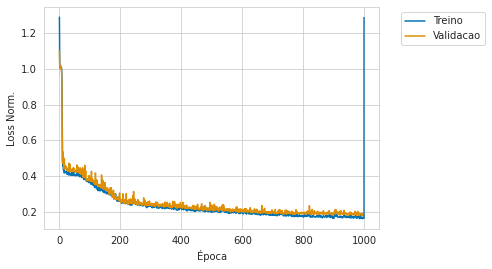

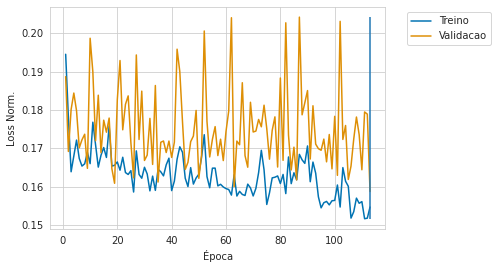

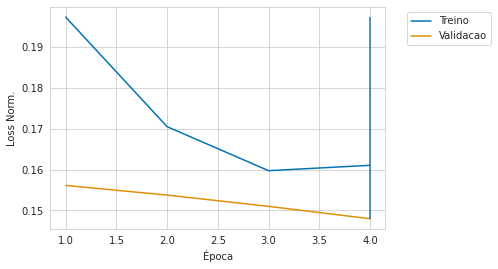

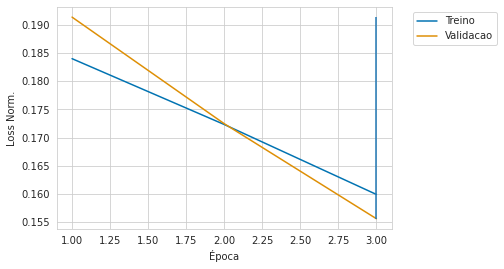

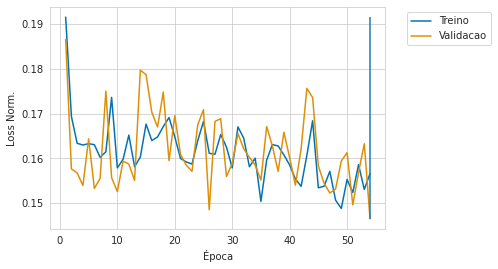

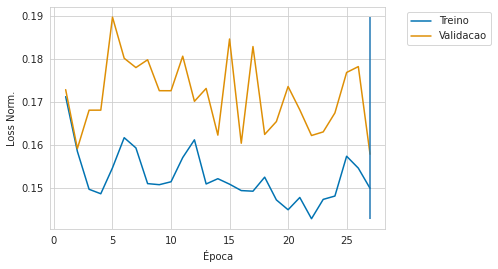

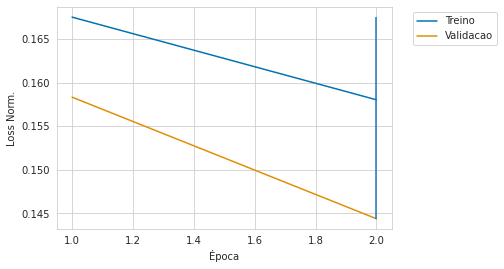

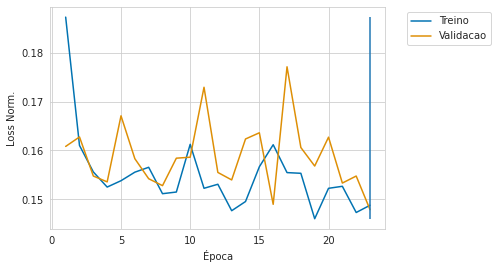

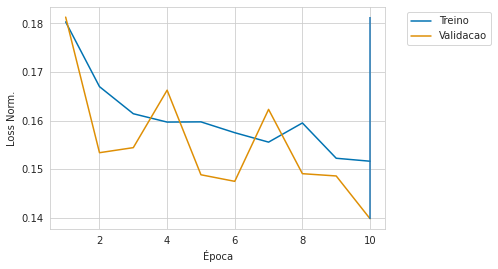

In [31]:
def fit_rede_neural(df, features, alvos, random_state = 42, model_ref = None):
    df_train = df_treino.sample(frac = 0.7, random_state = random_state)
    df_val = df_treino.drop(df_train.index)

    medias_train = df_train[alvos].mean(axis = 0)
    medias_val = df_val[alvos].mean(axis = 0)

    func_loss = keras.losses.MeanSquaredError()

    loss_train = func_loss(medias_train, df_train[alvos]).numpy()
    loss_val = func_loss(medias_val, df_val[alvos]).numpy()

    if(model_ref is None):
        model = cria_rede_neural(features, alvos)
    else:
        model = keras.models.clone_model(model_ref)
        model.set_weights(model_ref.get_weights())

    opt = tf.keras.optimizers.Adam(learning_rate = 0.01)
    model.compile(loss = func_loss, optimizer = opt)

    callback = tf.keras.callbacks.EarlyStopping(
                                                monitor = 'val_loss',
                                                min_delta = 0,
                                                patience = 50,
                                                verbose = False,
                                                mode = 'min',
                                                restore_best_weights = True
                                                )
    
    print_callback = LossPrintingCallback(loss_train, loss_val)

    curva_vies_variancia = [[], []]

    n_epocas = 1000
    n_batchs = 16

    H = model.fit(normalizacao(df_train, features, maximos, minimos), df_train[alvos],
                   validation_data = (normalizacao(df_val, features, maximos, minimos), df_val[alvos]),
                   epochs = n_epocas,
                   batch_size = int(np.ceil(df_train.shape[0]/n_batchs)), 
                   callbacks = [callback, print_callback],
                   verbose = False)

    argmin = np.argmin(H.history['val_loss'])
    curva_vies_variancia[0].extend(H.history['loss'][:argmin+1])
    curva_vies_variancia[1].extend(H.history['val_loss'][:argmin+1])

    return model, curva_vies_variancia, loss_train, loss_val

lista_seeds = np.arange(1, 10)
model = None
for s in lista_seeds:
    model, curva_vies_variancia, loss_train, loss_val = fit_rede_neural(df_treino, features, alvos, 
                                                                        random_state = s, 
                                                                        model_ref = model)
    plot_vies_variancia(curva_vies_variancia, loss_train, loss_val)

In [32]:
def f(X, Y, features, alvos):
    df_inp = pd.DataFrame(np.vstack([X.flatten(), Y.flatten()]).T, columns = features)
    pred = pd.DataFrame(model.predict(normalizacao(df_inp, features, maximos, minimos), verbose = False), columns = alvos)
    Z_alvos = {}
    for alvo in alvos:
            Z_alvos[alvo] = 100*pred[alvo].values.reshape(X.shape)
    return Z_alvos

### Mapa País

In [33]:
gdf_contorno = gdf_pais
gdf_contorno_interno = gdf_uf

In [34]:
#Cria Grid de Valores
n = 100
df_lim = pd.DataFrame(np.array(gdf_contorno.convex_hull.boundary.iloc[0].coords), columns = ['Longitude', 'Latitude'])
x = np.linspace(df_lim['Latitude'].min(), df_lim['Latitude'].max(), n)  
y = np.linspace(df_lim['Longitude'].min(), df_lim['Longitude'].max(), n)  
X, Y = np.meshgrid(x, y)
#Calcula Interpolação
Z = f(X, Y, features, alvos)

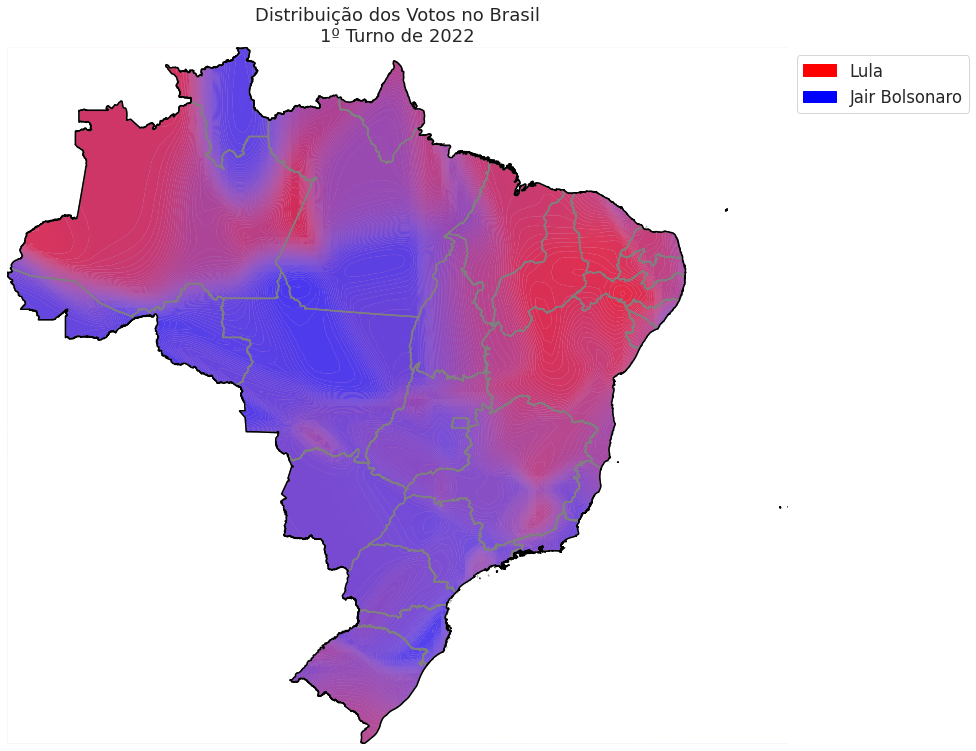

In [35]:
with sns.axes_style("whitegrid"), sns.plotting_context('notebook', font_scale = 1.5):
    fig, ax = plt.subplots(1, 1, figsize = (14, 14))

    for candidato in candidatos_sel:
        N = 256
        cor = dict_cores[candidato]
        vals = np.ones((N, 4))
        vals[:, 0] = cor[0]
        vals[:, 1] = cor[1]
        vals[:, 2] = cor[2]
        vals[:, 3] = np.linspace(0, 1, N)[::-1]
        cmap = mpl.colors.ListedColormap(vals[::-1])
        
        cntr = ax.contourf(Y, X, Z[candidato], levels = 100,
                           cmap = cmap,
                           norm = mpl.colors.Normalize(vmin = 0, vmax = 100, clip = False),
                           linestyles = None,
                           antialiased = True)

    #Limites do gráfico
    df_lim = pd.DataFrame(np.array(gdf_contorno.convex_hull.boundary.iloc[0].coords), columns = ['Longitude', 'Latitude'])
    ax.set_xlim([df_lim['Longitude'].min(), df_lim['Longitude'].max()])
    ax.set_ylim([df_lim['Latitude'].min(), df_lim['Latitude'].max()])
    #Contornos internos
    gdf_contorno_interno['geometry'].boundary.plot(ax = ax, color = 'grey')
    #Contornos externos
    (gdf_contorno['geometry'].envelope.difference(gdf_contorno['geometry'])).plot(ax = ax, color = 'white', edgecolor = None)
    gdf_contorno['geometry'].boundary.plot(ax = ax, color = 'black')
    #Remoção de Grades e Eixos
    ax.grid(False)
    frame = plt.gca()
    frame.axes.xaxis.set_ticklabels([])
    frame.axes.yaxis.set_ticklabels([])

    ax.legend(handles = hlds, bbox_to_anchor = (1.0, 1), loc = 'upper left')
    ax.set_title('Distribuição dos Votos no Brasil\n1º Turno de 2022')
    plt.box(False)
    plt.show()

### Mapa Estado

In [36]:
uf = 'MG'
gdf_contorno = gdf_uf[gdf_uf['SIGLA'] == uf]
gdf_contorno_interno = gdf_mun[gdf_mun['SIGLA'] == uf]

In [37]:
#Cria Grid de Valores
n = 100
df_lim = pd.DataFrame(np.array(gdf_contorno.convex_hull.boundary.iloc[0].coords), columns = ['Longitude', 'Latitude'])
x = np.linspace(df_lim['Latitude'].min(), df_lim['Latitude'].max(), n)  
y = np.linspace(df_lim['Longitude'].min(), df_lim['Longitude'].max(), n)  
X, Y = np.meshgrid(x, y)
#Calcula Interpolação
Z = f(X, Y, features, alvos)

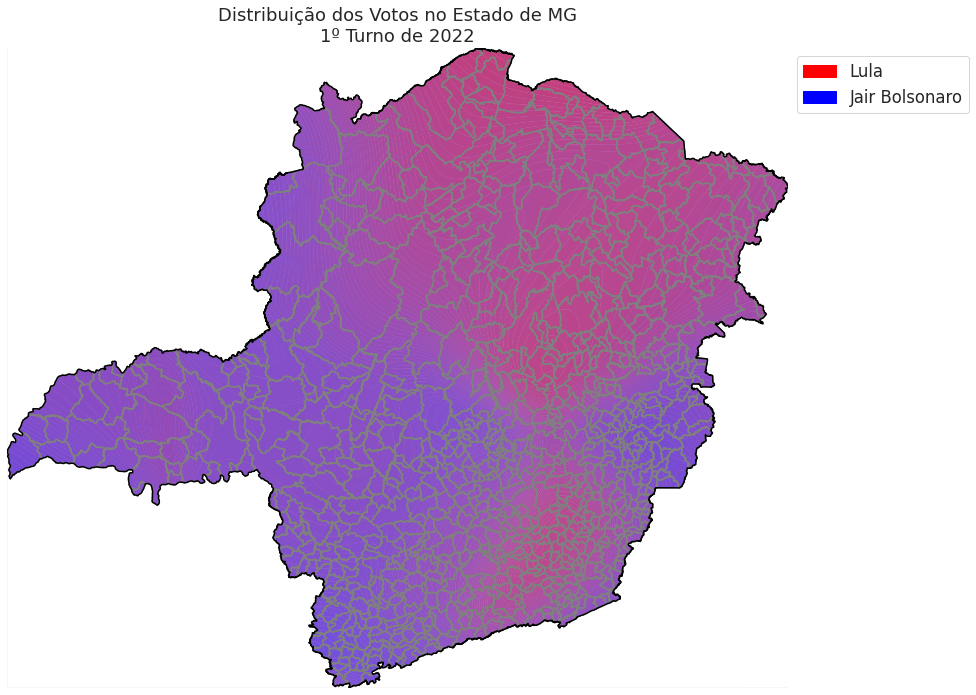

In [38]:
with sns.axes_style("whitegrid"), sns.plotting_context('notebook', font_scale = 1.5):
    fig, ax = plt.subplots(1, 1, figsize = (14, 14))

    for candidato in candidatos_sel:
        N = 256
        cor = dict_cores[candidato]
        vals = np.ones((N, 4))
        vals[:, 0] = cor[0]
        vals[:, 1] = cor[1]
        vals[:, 2] = cor[2]
        vals[:, 3] = np.linspace(0, 1, N)[::-1]
        cmap = mpl.colors.ListedColormap(vals[::-1])

        cntr = ax.contourf(Y, X, Z[candidato], levels = 100,
                           cmap = cmap,
                           norm = mpl.colors.Normalize(vmin = 0, vmax = 100, clip = False),
                           linestyles = None,
                           antialiased = True)

    #Limites do gráfico
    df_lim = pd.DataFrame(np.array(gdf_contorno.convex_hull.boundary.iloc[0].coords), columns = ['Longitude', 'Latitude'])
    ax.set_xlim([df_lim['Longitude'].min(), df_lim['Longitude'].max()])
    ax.set_ylim([df_lim['Latitude'].min(), df_lim['Latitude'].max()])
    #Contornos internos
    gdf_contorno_interno['geometry'].boundary.plot(ax = ax, color = 'grey')
    #Contornos externos
    (gdf_contorno['geometry'].envelope.difference(gdf_contorno['geometry'])).plot(ax = ax, color = 'white', edgecolor = None)
    gdf_contorno['geometry'].boundary.plot(ax = ax, color = 'black')
    #Remoção de Grades e Eixos
    ax.grid(False)
    frame = plt.gca()
    frame.axes.xaxis.set_ticklabels([])
    frame.axes.yaxis.set_ticklabels([])

    ax.legend(handles = hlds, bbox_to_anchor = (1.0, 1), loc = 'upper left')
    ax.set_title(f'Distribuição dos Votos no Estado de {uf}\n1º Turno de 2022')

    plt.box(False)
    plt.show()

### Mapa Cidade

In [39]:
cidade = 'São Paulo'
uf = 'SP'
flag_plot_setores = True

gdf_contorno = gdf_mun[(gdf_mun['NM_MUN'] == cidade) & (gdf_mun['SIGLA'] == uf)]
display(gdf_contorno)

gdf_contorno_interno = gdf_setor[(gdf_setor['NM_MUN'] == cidade) & (gdf_setor['SIGLA_UF'] == uf)]
if(gdf_contorno_interno['CD_DIST'].unique().size > 1):
    agrupamento = 'CD_DIST'
elif(gdf_contorno_interno['CD_SUBDIST'].unique().size > 1):
    agrupamento = 'CD_SUBDIST'
else:
    agrupamento = None
if agrupamento is not None:
    gdf_contorno_interno = gdf_contorno_interno[[agrupamento, 'geometry']].dissolve(by = agrupamento)
print(gdf_contorno_interno.shape)

,CD_MUN,NM_MUN,SIGLA,AREA_KM2,geometry
3829,3550308,São Paulo,SP,1521.202,"POLYGON ((-46.54624 -23.35791, -46.54585 -23.3..."


(96, 1)


In [40]:
#Cria Grid de Valores
n = 100
df_lim = pd.DataFrame(np.array(gdf_contorno.convex_hull.boundary.iloc[0].coords), columns = ['Longitude', 'Latitude'])
x = np.linspace(df_lim['Latitude'].min(), df_lim['Latitude'].max(), n)  
y = np.linspace(df_lim['Longitude'].min(), df_lim['Longitude'].max(), n)  
X, Y = np.meshgrid(x, y)
#Calcula Interpolação
Z = f(X, Y, features, alvos)

In [41]:
flag_plot_zonas_eleitorais = False

contorno_convex_tmp = gdf_contorno['geometry'].iloc[0].convex_hull
mask_interior_temp = gdf['geometry'].apply(lambda p: p.within(contorno_convex_tmp))
mask_interior_temp2 = gdf.loc[mask_interior_temp, 'geometry'].apply(lambda p: p.within(gdf_contorno['geometry'].iloc[0]))
gdf_plot_temp = gdf[mask_interior_temp][mask_interior_temp2.values]
print(gdf_plot_temp.shape)

hlds_temp = hlds.copy()
hlds_temp.append(mpl.lines.Line2D([0], [0], marker = 'o', markerfacecolor = 'black', markersize = 15, color = 'white',
                                  label = 'Zonas Eleitorais'))

(58, 16)


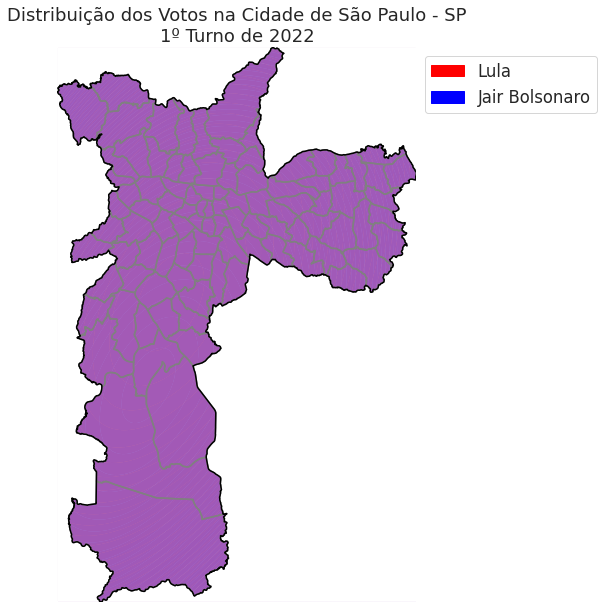

In [42]:
with sns.axes_style("whitegrid"), sns.plotting_context('notebook', font_scale = 1.5):
    fig, ax = plt.subplots(1, 1, figsize = (10, 10))

    for candidato in candidatos_sel:
        N = 256
        cor = dict_cores[candidato]
        vals = np.ones((N, 4))
        vals[:, 0] = cor[0]
        vals[:, 1] = cor[1]
        vals[:, 2] = cor[2]
        vals[:, 3] = np.linspace(0, 1, N)[::-1]
        cmap = mpl.colors.ListedColormap(vals[::-1])

        cntr = ax.contourf(Y, X, Z[candidato], levels = 100,
                           cmap = cmap,
                           norm = mpl.colors.Normalize(vmin = 0, vmax = 100, clip = False),
                           linestyles = None,
                           antialiased = True)

    #Limites do gráfico
    df_lim = pd.DataFrame(np.array(gdf_contorno.convex_hull.boundary.iloc[0].coords), columns = ['Longitude', 'Latitude'])
    ax.set_xlim([df_lim['Longitude'].min(), df_lim['Longitude'].max()])
    ax.set_ylim([df_lim['Latitude'].min(), df_lim['Latitude'].max()])
    #Contornos internos
    if flag_plot_setores:
        gdf_contorno_interno['geometry'].boundary.plot(ax = ax, color = 'grey',
                                                       #lw = 1,
                                                       alpha = 1, 
                                                       )
    #Contornos externos
    (gdf_contorno['geometry'].envelope.difference(gdf_contorno['geometry'])).plot(ax = ax, color = 'white', edgecolor = None)
    gdf_contorno['geometry'].boundary.plot(ax = ax, color = 'black')
    #Remoção de Grades e Eixos
    ax.grid(False)
    frame = plt.gca()
    frame.axes.xaxis.set_ticklabels([])
    frame.axes.yaxis.set_ticklabels([])

    #Plota as Zonas Eleitorais
    if flag_plot_zonas_eleitorais:
        ax.scatter(gdf_plot_temp['Longitude'], gdf_plot_temp['Latitude'], color = 'black')
        ax.legend(handles = hlds_temp, bbox_to_anchor = (1.0, 1), loc = 'upper left')
    else:
        ax.legend(handles = hlds, bbox_to_anchor = (1.0, 1), loc = 'upper left')

    ax.set_title(f'Distribuição dos Votos na Cidade de {cidade} - {uf}\n1º Turno de 2022')

    plt.box(False)
    plt.show()